# Present
The Dataset present about the difference of weat seed characteristics. There are 7 features including  
1.area A

2.perimeter P

3.compactness C = 4piA/P^2

4.length of kerne

5.width of kernel

6.asymmetry coefficient

7.length of kernel groove


1. area A :พื้นที่ของเมล็ดในภาพ 2D
2. perimeter P :ความยาวรอบขอบเขตของเมล็ด
3. compactness C = 4*pi*A/P^2 :รูปร่างใกล้วงกลมแค่ไหน
4. length of kerne :ความยาวเมล็ด
5. width of kernel:ความกว้างเมล็ด
6. asymmetry coefficient : วัดว่าเมล็ดเอียงหรือเบี้ยวจากแกนกลางแค่ไหน
7. length of kernel groove :     (crease/groove)

# Analysis & Modeling
We will develope an appropriated classification model to identify and predict the varities of weat seeds and analyze feature which high influence. The model is considered to be SVM/ Logistic Regression.Due to the dataset are small size(n=210) with low-dimensional features (7 features) and Balanced data.

# Technique
1.Feature Extraction using Linear Discriminant Analysis (LDA) because
LDA is supervised learning dimensionality reduction technique and Machine Learning classifier. Furthermore, it Works well on small datasets. These LDA character are appropriate for the goal, Classify the varieties of weat seeds and help us retrive Feature Influence Insight.

# Process
1. ตรวจสอบข้อมูลเบื้องต้น เพื่อหาว่าข้อมูลเหมาะกับเครื่องมือใด
2.กำหนดวัตถุประสงค์โดยเลือกทำ Classification เพือสร้างโมเดลทำนาย class ของข้อมูล เลือกใช้ LDA ในการทำ Feature Extraction เพื่อหา factor ที่มีผลกับการจำแนก class ข้อมูล และทำ Classification
3.ตรวจสอบการแจกแจงของข้อมูล (ข้อมูลต้องมีการแจกแจง Gaussian)
4.ตรวจสอบ Outlier
5.Apply LDA to manipulate and develope modal.
6. Train/Test Model
7. Evaluate model
8. Optimization (จูนโมเดล)
9. สรุปผล


In [ ]:
import numpy as np
import pandas as pd
import scipy.special
import scipy.stats as st
import sklearn
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:


# ชื่อคอลัมน์
columns = [
    "area A",
    "perimeter P",
    "compactness C",
    "Kernel_Length",
    "Kernel_Width",
    "Asymmetry_Coeff",
    "GrooveLength",
    "Class"
]

# อ่านไฟล์ txt (คั่นด้วย space)
df = pd.read_csv("/content/drive/MyDrive/TOOL4STAT/seeds_dataset.txt", sep="\s+", header=None)

# ใส่หัวตาราง
df.columns = columns

# บันทึกไฟล์ใหม่
#df.to_csv("wheat_with_header.txt", sep="\t", index=False)


<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_24870/3588157355.py:14: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("/content/drive/MyDrive/TOOL4STAT/seeds_dataset.txt", sep="\s+", header=None)


# Data Exploration

In [ ]:
df.head()

,area A,perimeter P,compactness C,Kernel_Length,Kernel_Width,Asymmetry_Coeff,GrooveLength,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [ ]:
#unique values for each column
df.nunique()


,0
area A,193
perimeter P,170
compactness C,186
Kernel_Length,188
Kernel_Width,184
Asymmetry_Coeff,207
GrooveLength,148
Class,3


In [ ]:
'''
df["Weat_Variety"] = df["Class"].map({
    1: "Kama",
    2: "Rosa",
    3: "Canadian"
})
'''


In [ ]:
df.head()

,area A,perimeter P,compactness C,Kernel_Length,Kernel_Width,Asymmetry_Coeff,GrooveLength,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [ ]:
import matplotlib.pyplot as plt

Class
1    70
2    70
3    70
Name: count, dtype: int64


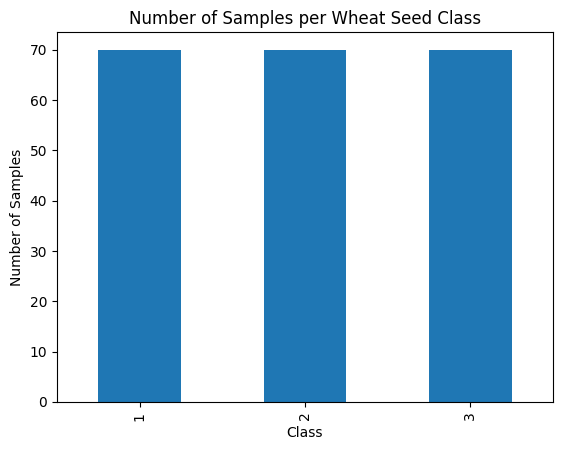

In [ ]:
class_counts = df["Class"].value_counts()
print(class_counts)

class_counts.plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Number of Samples per Wheat Seed Class")
plt.show()


In [ ]:
df.isnull().sum()


,0
area A,0
perimeter P,0
compactness C,0
Kernel_Length,0
Kernel_Width,0
Asymmetry_Coeff,0
GrooveLength,0
Class,0


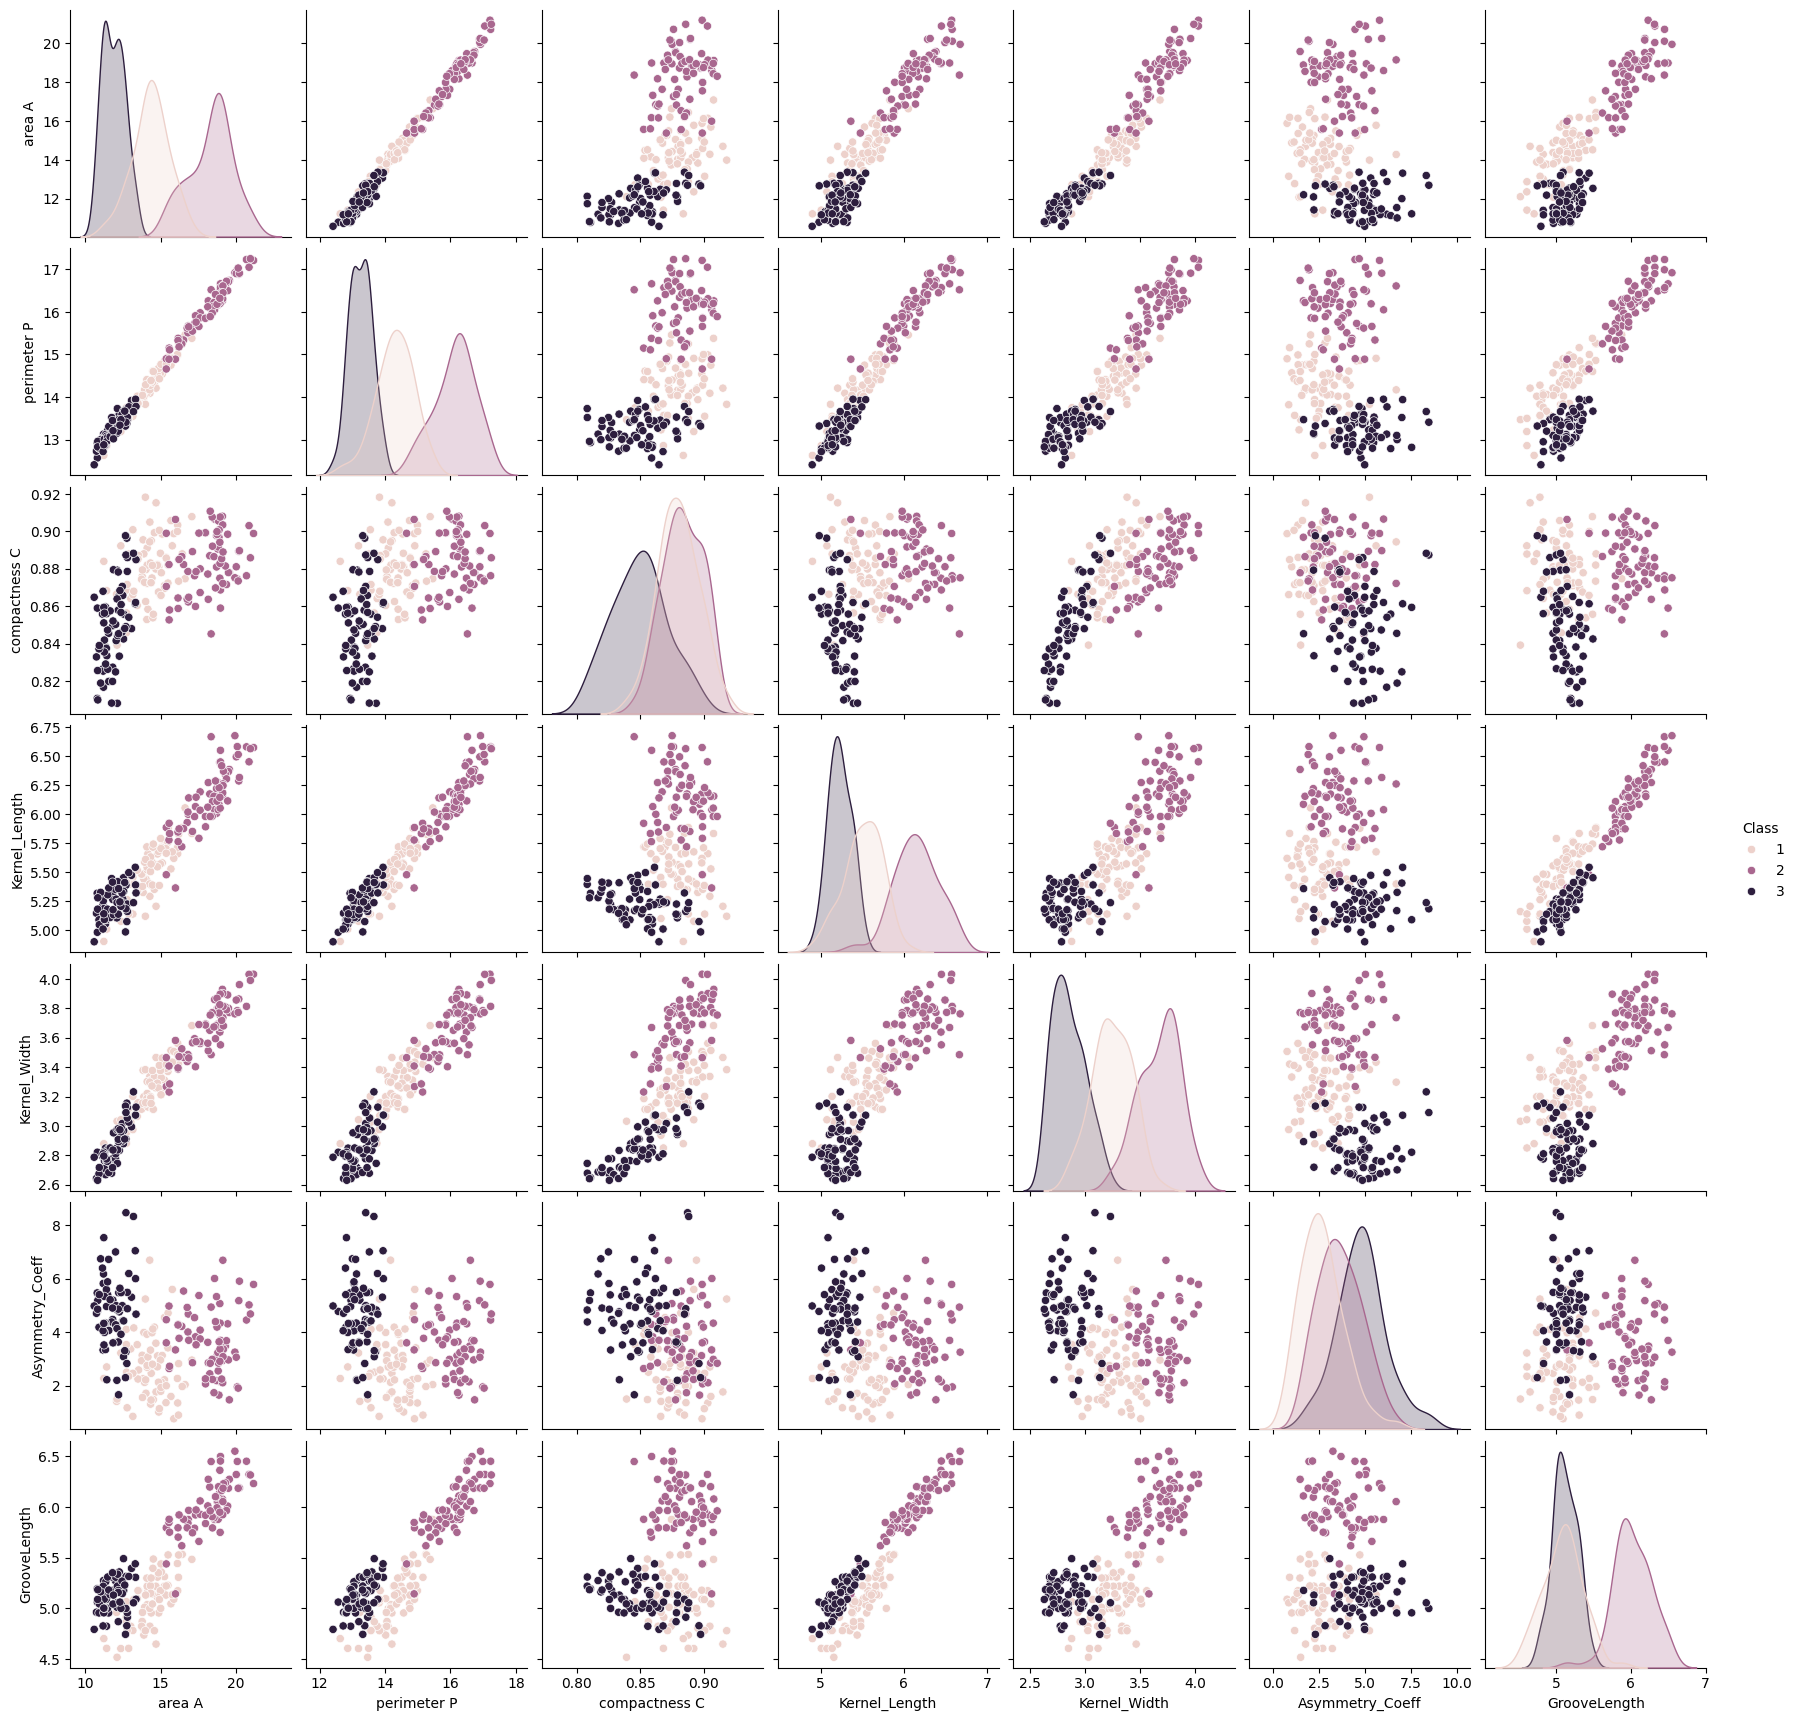

In [ ]:

# Plot pairwise comparison to explore the data
sns.pairplot(df, hue='Class')

### Distribution Interpretation
Some features arised in overlapping (ทับซ้อน)

## Key Assumptions of LDA
For LDA to perform effectively, certain assumptions are made:

- Gaussian Distribution: The data in each class should follow a normal bell-shaped distribution.

- Equal Covariance Matrices: All classes should have the same covariance structure.
- Linear Separability: The data should be separable using a straight line or plane.

https://www.geeksforgeeks.org/machine-learning/ml-linear-discriminant-analysis/

# 1. MEAN & VARIANCE

ค่าเฉลี่ยของแต่ละกลุ่มแยกออกจากกันอย่างเห็นได้ชัดในทุก Features

In [ ]:
# ดูค่าเฉลี่ยของแต่ละ Feature แยกตาม Class
means = df.groupby('Class').mean()
print(means)

from scipy.spatial.distance import pdist, squareform
import pandas as pd

# 1. หาค่าเฉลี่ย (Centroids) ของแต่ละคลาส
means = df.groupby('Class').mean()

# 2. คำนวณ Euclidean Distance ระหว่างทุกคู่แถว (ทุก Class)
dist_matrix = squareform(pdist(means, metric='euclidean'))

# 3. แปลงเป็น DataFrame เพื่อให้อ่านง่าย
dist_df = pd.DataFrame(dist_matrix, index=means.index, columns=means.index)

print("Distance Matrix between Class Centroids:")
print(dist_df)

          area A  perimeter P  compactness C  Kernel_Length  Kernel_Width  \
Class                                                                       
1      14.334429    14.294286       0.880070       5.508057      3.244629   
2      18.334286    16.135714       0.883517       6.148029      3.677414   
3      11.873857    13.247857       0.849409       5.229514      2.853771   

       Asymmetry_Coeff  GrooveLength  
Class                                 
1             2.667403      5.087214  
2             3.644800      6.020600  
3             4.788400      5.116400  
Distance Matrix between Class Centroids:
Class         1         2         3
Class                              
1      0.000000  4.670451  3.446767
2      4.670451  0.000000  7.329766
3      3.446767  7.329766  0.000000


In [ ]:

# 2. หาค่าความแปรปรวน (Variance) ของแต่ละคลาส
variances = df.groupby('Class').var()
print("\n--- Variance of each class ---")
print(variances)


--- Variance of each class ---
         area A  perimeter P  compactness C  Kernel_Length  Kernel_Width  \
Class                                                                      
1      1.477935     0.332448       0.000262       0.053596      0.031547   
2      2.072149     0.380683       0.000240       0.071926      0.034425   
3      0.522734     0.115733       0.000473       0.019048      0.021761   

       Asymmetry_Coeff  GrooveLength  
Class                                 
1             1.378044      0.069537  
2             1.396813      0.064482  
3             1.786139      0.026266  


# 2.Correlation Matrix

### Feature extraction

It can be used to **reduce the dimensionality of the data** while preserving the class information. It can improve the subsequent analysis’s efficiency and accuracy, such as classification or clustering. It can extract the most discriminative features from a high-dimensional dataset of images, texts, or sounds and use them for recognition or classification tasks.

    ถึงแม้จะพบว่าค่า Correlation หลายคู่ค่อนข้างสูง แต่ LDA มีคุณสมบัติในการทำ Dimentional Reduction ซึ่งจะสามารถจัดการกับปัญหานี้ได้โดยไม่กระทบต่อประสิทธิภาพโมเดล

    Focus on Class Separation:
    เป้าหมายสูงสุดของ LDA คือการหาช่องว่างระหว่างคลาส (Between-class variance) ต่อความแปรปรวนภายในคลาส (Within-class variance) ตราบใดที่ฟีเจอร์ที่ Correlation สูงเหล่านั้นช่วยให้ "ช่องว่างระหว่างคลาส" ชัดเจนขึ้น LDA ก็จะดึงประสิทธิภาพออกมาได้เต็มที่

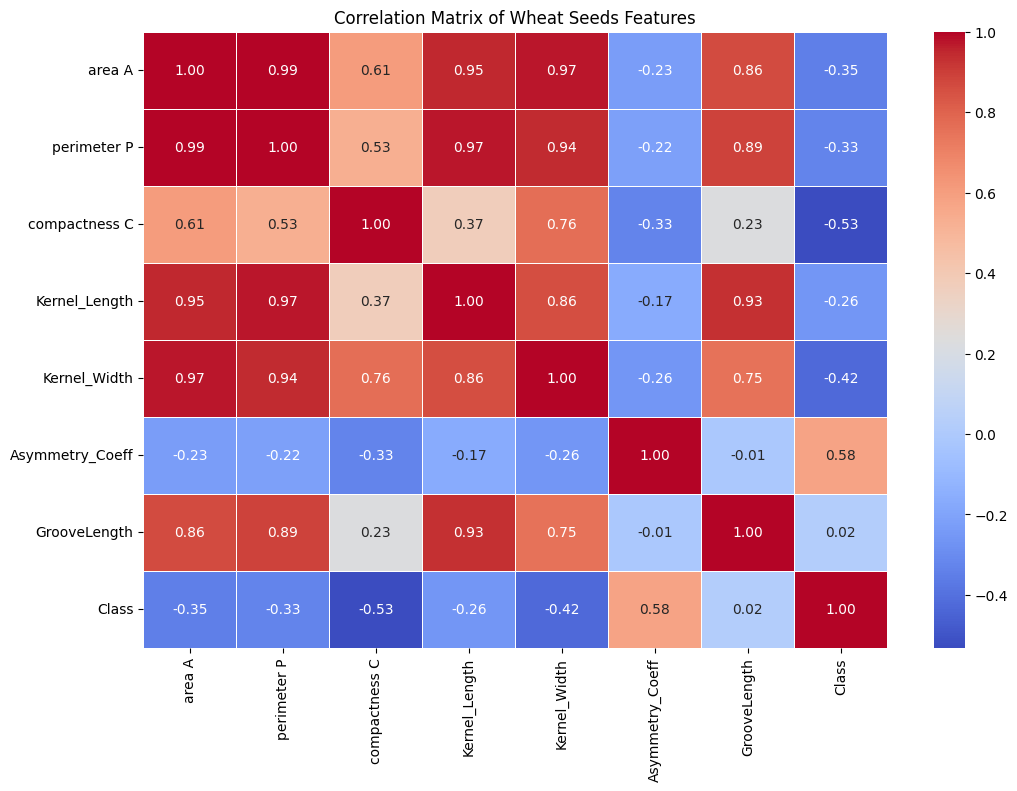

In [ ]:
# 1. คำนวณค่า Correlation (ค่าเริ่มต้นคือ Pearson)
corr_matrix = df.corr()

# 2. ตั้งค่าขนาดกราฟ
plt.figure(figsize=(12, 8))

# 3. สร้าง Heatmap
# annot=True เพื่อแสดงตัวเลขในช่อง
# cmap='coolwarm' สีแดงคือบวก (สัมพันธ์ตามกัน) สีฟ้าคือลบ (สัมพันธ์สวนทาง)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix of Wheat Seeds Features')
plt.show()

# 3. Divided data inyo 3 set, Preventing Data Lakage

In [ ]:
from sklearn.model_selection import train_test_split

# 1. แยก Features (X) และ Target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 2. แบ่งรอบแรก: แยก Test ออกไปก่อน 15% (เหลือ Train+Val 85%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# 3. แบ่งรอบสอง: แยก Train และ Validation จากก้อน 85% ที่เหลือ
# (0.176 ของ 85% จะเท่ากับประมาณ 15% ของทั้งหมด)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val
)

print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

Train size: 146, Val size: 32, Test size: 32


In [ ]:
X_train.columns

Index(['area A', 'perimeter P', 'compactness C', 'Kernel_Length',
       'Kernel_Width', 'Asymmetry_Coeff', 'GrooveLength'],
      dtype='object')

In [ ]:
X_test.columns

Index(['area A', 'perimeter P', 'compactness C', 'Kernel_Length',
       'Kernel_Width', 'Asymmetry_Coeff', 'GrooveLength'],
      dtype='object')

## 4.Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit เฉพาะ Train และ Transform ทั้ง 3 ส่วน
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 5. Covariance Matrix
Assumes equal covariance matrices for different classes which may not hold in all datasets.


    เพื่อตรวจสอบว่า Covariance ของแต่ละคลาสเท่ากันหรือไม่ ซึ่งจากผลลัพธ์ ถือว่ามีความใกล้เคียงกัน

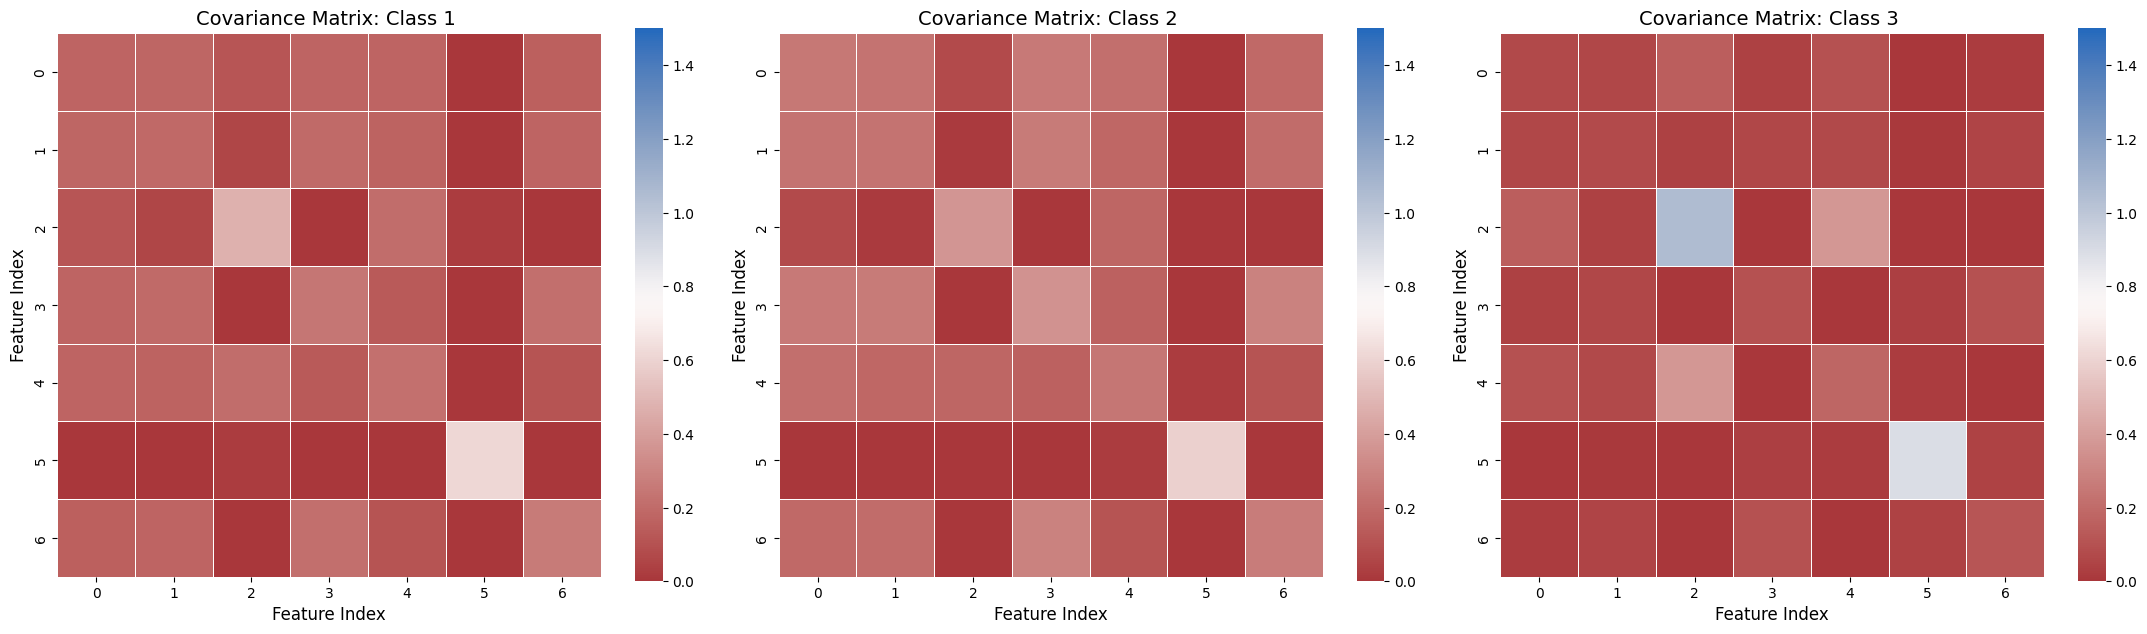

In [ ]:


classes = sorted(y_train.unique())
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# กำหนดช่วงสี (vmin, vmax) ให้เท่ากันทุกรูป เพื่อให้สีสันเปรียบเทียบกันได้จริงๆ
# สำหรับ Covariance ของข้อมูลที่ Scale แล้ว ค่ามักจะอยู่ระหว่าง 0 ถึง 2-3
v_min = 0
v_max = 1.5

for i, cls in enumerate(classes):
    # คำนวณ Covariance Matrix ของคลาสนั้นๆ
    cls_cov = pd.DataFrame(X_train_scaled[y_train == cls]).cov()

    # พลอต Heatmap
    sns.heatmap(cls_cov,
                annot=False, # ปิดตัวเลขเพื่อความสะอาดตา (ดูแค่ Pattern สี)
                cmap='vlag_r', # โทนสีพาสเทลอุ่นๆ (Blue-White-Red reverse)
                ax=axes[i],
                cbar=True, # เปิด Colorbar ด้านขวา
                vmin=v_min,
                vmax=v_max,
                square=True, # บังคับให้ช่องเป็นสี่เหลี่ยมจัตุรัส
                linewidths=0.5) # ใส่เส้นขอบบางๆ ระหว่างช่อง

    axes[i].set_title(f'Covariance Matrix: Class {cls} ', fontsize=14)
    axes[i].set_xlabel('Feature Index', fontsize=12)
    axes[i].set_ylabel('Feature Index', fontsize=12)

plt.tight_layout()
plt.show()

# 6.Test Gaussian Distribution
The condition of LDA, LDA requires Gaussian distribution.

    หนึ่งในเงื่อนไขของ LDA คือ ข้อมูลต้องมีการแจกแจงแบบ Gaussian หรือ Normal



In [ ]:
from scipy import stats

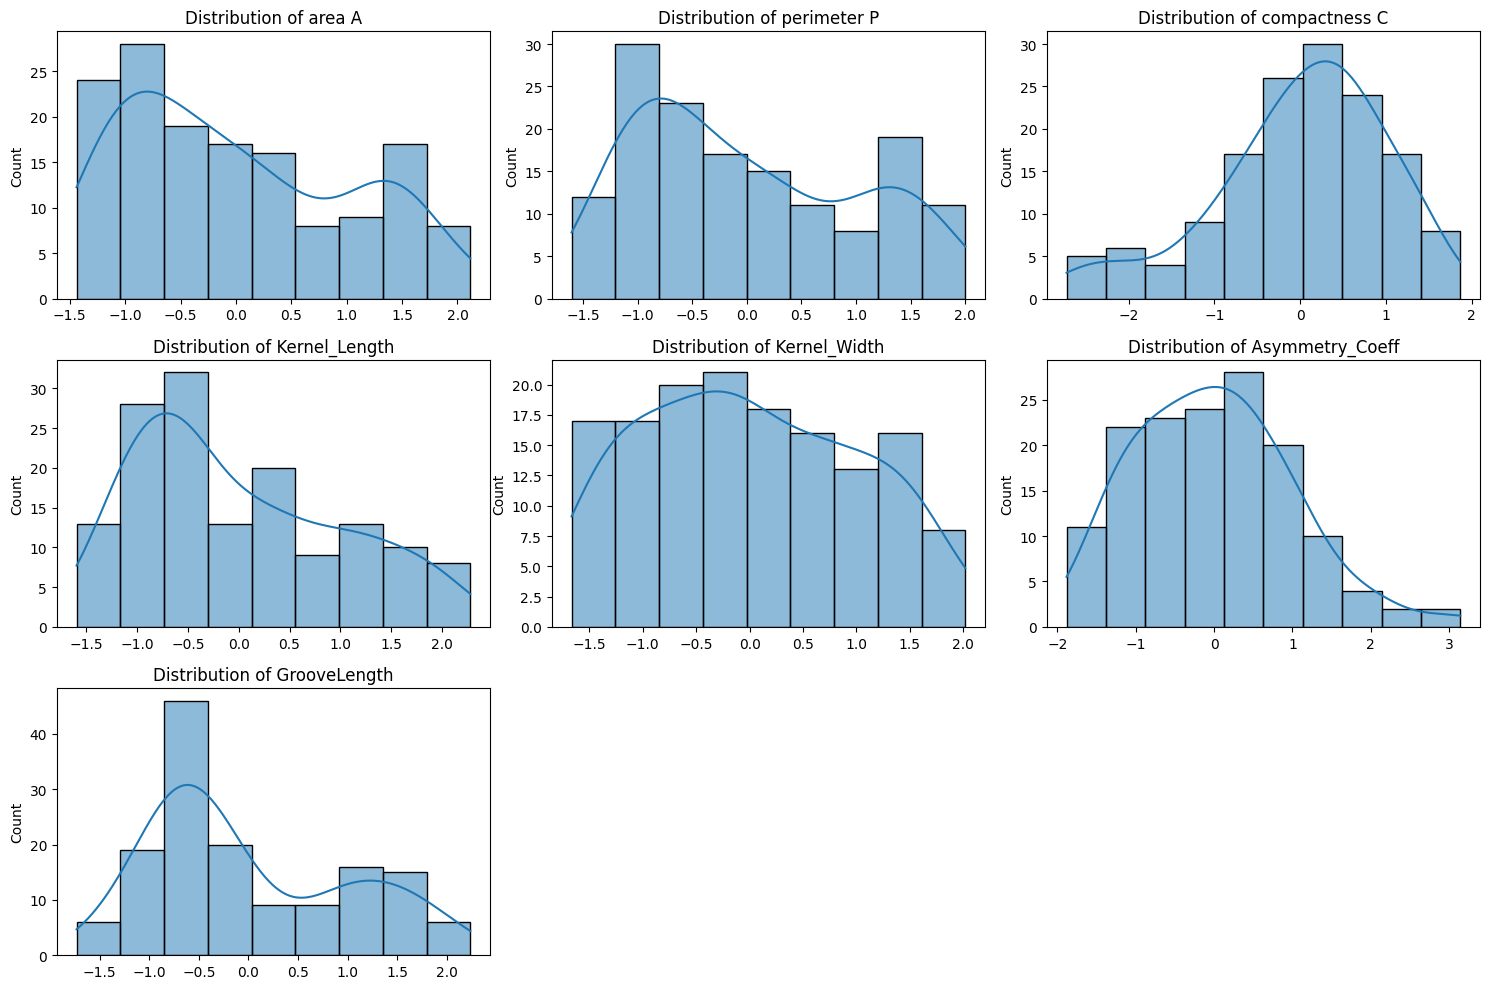

In [ ]:
# แบบไม่แยกคลาส
plt.figure(figsize=(15, 10))
for i, col in enumerate(X.columns):
    plt.subplot(3, 3, i+1)
    sns.histplot(X_train_scaled[:, i], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import shapiro

# 1. รวม X_train ที่ scale แล้ว กับ y_train เข้าด้วยกันก่อนเพื่อเช็คแยกคลาสได้ง่าย
train_data_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
train_data_scaled['Class'] = y_train.values  # ใส่ labels กลับเข้าไป

# 2. วนลูปทดสอบ Shapiro-Wilk บนข้อมูล Training นี้
for class_id in sorted(train_data_scaled['Class'].unique()):
    print(f"\n--- Normal Distribution Test for Class {class_id} (Training Set) ---")

    # ดึงเฉพาะข้อมูลของคลาสนั้นๆ ออกมา
    class_data = train_data_scaled[train_data_scaled['Class'] == class_id].drop(columns='Class')

    for col in class_data.columns:
        stat, p = shapiro(class_data[col])
        status = "✅ Normal" if p > 0.05 else "❌ Non-Gaussian"
        print(f"{col:20}: p-value = {p:.4f} ({status})")


--- Normal Distribution Test for Class 1 (Training Set) ---
area A              : p-value = 0.9683 (✅ Normal)
perimeter P         : p-value = 0.7807 (✅ Normal)
compactness C       : p-value = 0.9587 (✅ Normal)
Kernel_Length       : p-value = 0.2382 (✅ Normal)
Kernel_Width        : p-value = 0.9766 (✅ Normal)
Asymmetry_Coeff     : p-value = 0.0115 (❌ Non-Gaussian)
GrooveLength        : p-value = 0.4797 (✅ Normal)

--- Normal Distribution Test for Class 2 (Training Set) ---
area A              : p-value = 0.0463 (❌ Non-Gaussian)
perimeter P         : p-value = 0.0727 (✅ Normal)
compactness C       : p-value = 0.0914 (✅ Normal)
Kernel_Length       : p-value = 0.3788 (✅ Normal)
Kernel_Width        : p-value = 0.4933 (✅ Normal)
Asymmetry_Coeff     : p-value = 0.8994 (✅ Normal)
GrooveLength        : p-value = 0.1053 (✅ Normal)

--- Normal Distribution Test for Class 3 (Training Set) ---
area A              : p-value = 0.0960 (✅ Normal)
perimeter P         : p-value = 0.5647 (✅ Normal)
compa

  ผลลัพธ์จากการทดสอบการแจกแจง Normal โดยใช้ Shapiro-Wilk

    ยังมีบางฟีเจอร์ที่ไม่เป็น Normal Distribution ซึ่งเราจะปรับโดยใช้ PowerTransformation ก่อน Train Model

## When to Use the Shapiro-Wilk Test
The Shapiro-Wilk test is a statistical test used to determine whether a sample comes from a normally distributed population.
Use this test when:

- You need to verify normality before applying parametric tests.

- Your sample size is small to moderate (e.g., n < 2000).

- You prefer a test with high power to detect departures from normality.

https://medium.com/@data-overload/the-shapiro-wilk-test-a-guide-to-normality-testing-d730e820d1a8


#7. Separability - LDA Feasibility

ด้านความสามารถในการแยกแยะ (Separability - LDA Feasibility):

- Area A, Parimeter P, Kernel_Length, Kernel_Width ค่าเฉลี่ยของแต่ละกลุ่มค่อนข้างห่างกันชัดเจน คือฟีเจอร์เหล่านี้มีความสามารถในการแยกแยะคลาสได้ค่อนข้างดี หรือ เป็น

  ฟีเจอร์ที่มีพลังในการแยกแยะสูง (High Discriminatory Power):
  Area A, Perimeter P, Kernel_Length และ Kernel_Width ฟีเจอร์กลุ่มนี้จะส่งผลบวกอย่างมากต่อค่า Eigenvalues ของ LDA ทำให้โมเดลสามารถลากเส้นแบ่ง (Decision Boundary) เพื่อแยกคลาสออกจากกันได้ง่าย


- จะเห็นว่า Class1 กับ Class3 มีคุณลักษณะหลายอย่างที่ใกล้เคียงกัน แต่ Class2 ส่วนมากจะแยกตัวออกไป โดยเฉพาะใน feature GrooveLength ที่แยก Class 2 ออกจากกลุ่มอื่นได้อย่างชัดเจนที่สุด
- Compactness C เป็นฟีเจอร์ที่ class ทั้ง3 มีค่าใกล้เคียงกันมาก จะเห็นว่าค่าเฉลี่ยของทั้ง 3 คลาสใกล้กันมาก


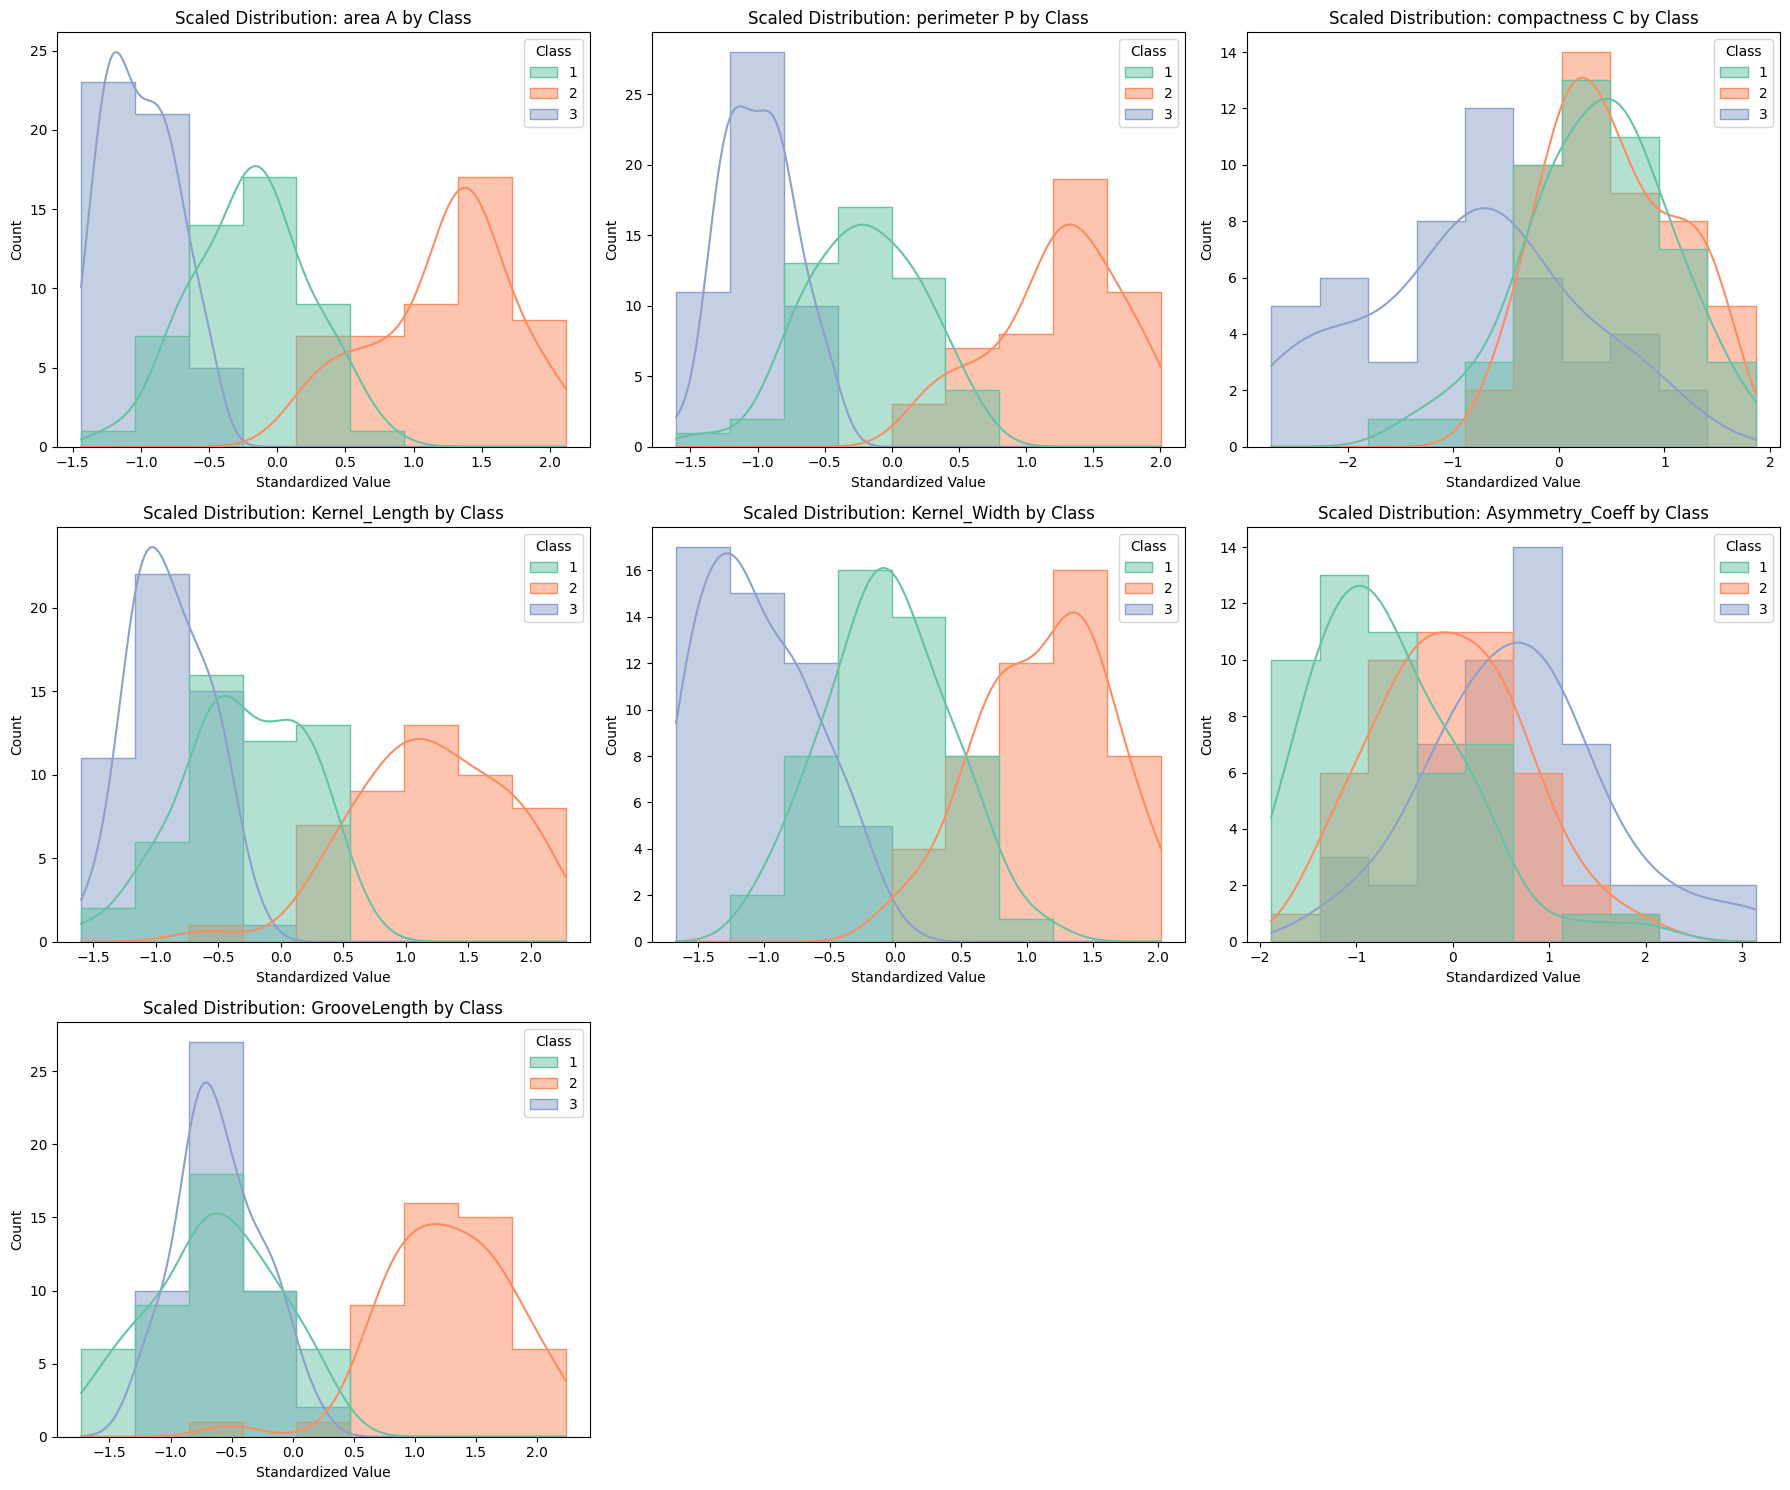

In [ ]:
# 1. เตรียม Data สำหรับ Plot (รวม X_train_scaled กับ y_train)
# สมมติ X_train_scaled คือผลจาก PowerTransformer
plot_df = pd.DataFrame(X_train_scaled, columns=X.columns)
plot_df['Class'] = y_train.values

# 2.
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    # ใช้ palette 'GnBu' หรือ 'Set2' ตามความชอบโทนเย็น
    sns.histplot(data=plot_df, x=col, hue='Class', kde=True, element="step",
                 palette='Set2', ax=axes[i], alpha=0.5)

    axes[i].set_title(f'Scaled Distribution: {col} by Class', fontsize=12)
    axes[i].set_xlabel('Standardized Value') # เปลี่ยนชื่อแกนให้ตรงความจริง
    axes[i].set_ylabel('Count')

# ลบช่องที่ไม่ได้ใช้
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#8. Training Model

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

### PowerTransformation

Apply a power transform featurewise to make data more Gaussian-like. This is useful for modeling issues related to heteroscedasticity (non-constant variance), or other situations where normality is desired.

PowerTransformation ใช้เพื่อปรับให้ข้อมูลบางอันมีการแจกแจงแบบ Normal  ( ตามเงื่อนไขของ LDA)

In [ ]:
# Apply Yeo-Johnson to transform Non-Gaussian
model = Pipeline([
    ('pt', PowerTransformer(method='yeo-johnson')),
    ('lda', LinearDiscriminantAnalysis())
])

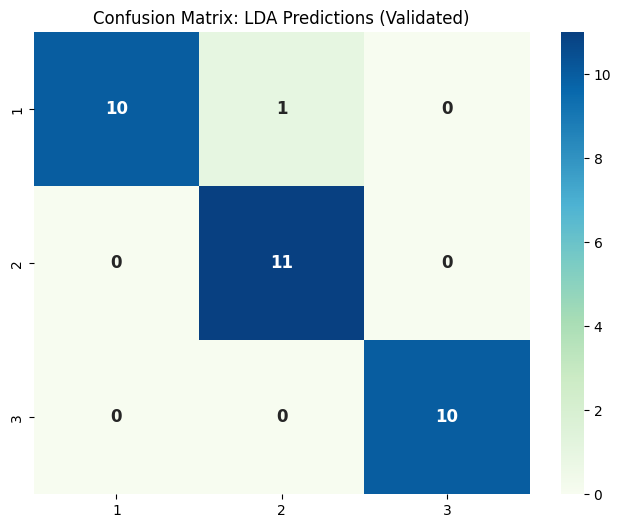

In [ ]:
# 1. Fit โมเดล
model.fit(X_train, y_train)

# 2. ทำนายผล (Predict) ก่อนเสมอ!
y_pred = model.predict(X_val)

# 3. นำ y_pred มาทำ Confusion Matrix
cm = confusion_matrix(y_val, y_pred)

# 4. พล็อต Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='GnBu',
            xticklabels=model.classes_, yticklabels=model.classes_,
            annot_kws={"size": 12, "weight": "bold"})
plt.title('Confusion Matrix: LDA Predictions (Validated)')
plt.show()


# 9. Confusion Matrix

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. แบ่งข้อมูลใหม่ให้ชัวร์ (ใช้ random_state เดิมเพื่อคุมผลลัพธ์)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Fit โมเดลผ่าน Pipeline เดิมของคุณ
model.fit(X_train, y_train)

# 3. Predict จาก X_test ชุดล่าสุด
y_pred = model.predict(X_test)

# 4. ดู Report อีกครั้ง
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      0.86      0.92        14
           2       1.00      1.00      1.00        14
           3       0.88      1.00      0.93        14

    accuracy                           0.95        42
   macro avg       0.96      0.95      0.95        42
weighted avg       0.96      0.95      0.95        42



## Macro average vs Weighted average
Both are used to evaluate model performance in multi-class and imbalanced classification problems. In such scenarios where standard metrics like precision and recall can produce misleading results especially when class distributions are skewed these averaging techniques offer a more reliable way to summarize performance across all classes by adjusting for class importance or frequency.

https://www.geeksforgeeks.org/machine-learning/macro-average-vs-weighted-average/

--ค่า Weighted Avg และ Macro Avg ออกมาเท่ากันที่ 0.95 ยืนยันว่าโมเดลไม่ได้ลำเอียงไปที่คลาสใดคลาสหนึ่ง

#10. Result

<Axes: xlabel='LD1', ylabel='LD2'>

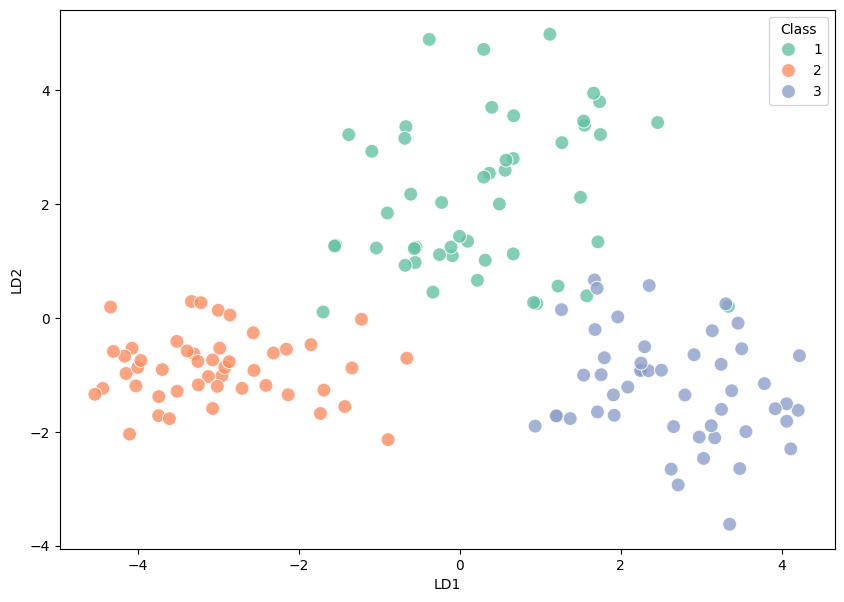

In [ ]:
# 1. ดึงเฉพาะตัวโมเดล LDA และ PowerTransformer ออกจาก Pipeline (ที่เทรนแล้ว)
lda_model = model.named_steps['lda']
pt_model = model.named_steps['pt']

# 2. Transform ข้อมูล X_train ให้เป็นแกน LDA
X_train_transformed = pt_model.transform(X_train)
X_lda = lda_model.transform(X_train_transformed)

# 3. สร้าง DataFrame สำหรับพลอต
lda_df = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
lda_df['Class'] = y_train.values

# 4. พลอตกราฟด้วยโทนสีพาสเทลน่ารักๆ
plt.figure(figsize=(10, 7))
sns.scatterplot(data=lda_df, x='LD1', y='LD2', hue='Class',
                palette='Set2', s=100, alpha=0.8, edgecolor='w')


In [ ]:
# ดูว่า Feature ไหนมีอิทธิพลต่อ LD1 มากที่สุด
loadings = pd.DataFrame(lda_model.scalings_, index=X.columns, columns=['LD1', 'LD2'])
print("Feature Importance for LDA:")
print(loadings.abs().sort_values(by='LD1', ascending=False))

Feature Importance for LDA:
                      LD1       LD2
area A           3.293879  1.866723
Kernel_Width     0.720706  2.582864
Kernel_Length    0.708013  3.468403
perimeter P      0.646107  0.413120
compactness C    0.633805  0.914639
GrooveLength     0.227484  3.435304
Asymmetry_Coeff  0.107941  0.400258


/tmp/ipykernel_24870/3494000941.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_loadings['LD1'], y=plot_loadings.index, ax=ax[0], palette='viridis')
/tmp/ipykernel_24870/3494000941.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_loadings_ld2['LD2'], y=plot_loadings_ld2.index, ax=ax[1], palette='magma')


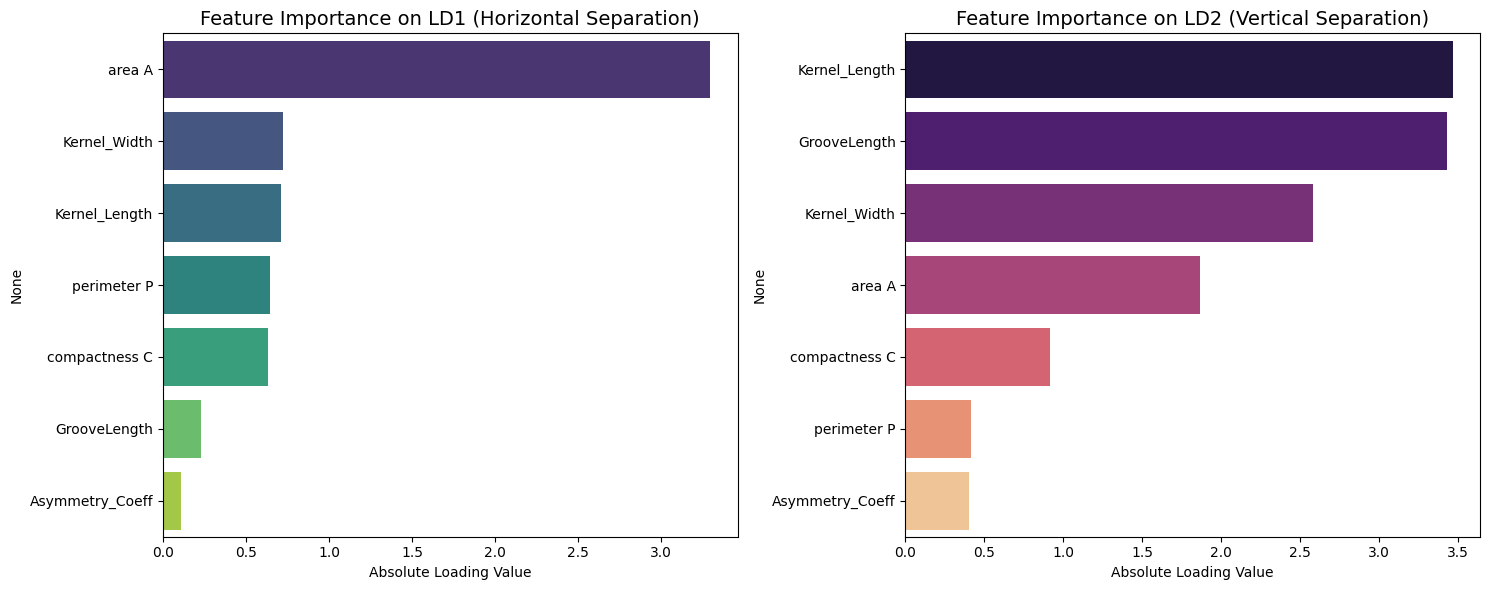

In [ ]:
# 1. เตรียมข้อมูลสำหรับพล็อต (ใช้ค่า Absolute เพื่อดูขนาดอิทธิพล)
plot_loadings = loadings.abs().sort_values(by='LD1', ascending=False)

# 2. สร้างกราฟ
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# กราฟสำหรับ LD1 (แกนหลักที่แยก Class 2)
sns.barplot(x=plot_loadings['LD1'], y=plot_loadings.index, ax=ax[0], palette='viridis')
ax[0].set_title('Feature Importance on LD1 (Horizontal Separation)', fontsize=14)
ax[0].set_xlabel('Absolute Loading Value')

# กราฟสำหรับ LD2 (แกนที่แยก Class 1 & 3)
plot_loadings_ld2 = loadings.abs().sort_values(by='LD2', ascending=False)
sns.barplot(x=plot_loadings_ld2['LD2'], y=plot_loadings_ld2.index, ax=ax[1], palette='magma')
ax[1].set_title('Feature Importance on LD2 (Vertical Separation)', fontsize=14)
ax[1].set_xlabel('Absolute Loading Value')

plt.tight_layout()
plt.show()

    สอดคล้องกับการทำ EDA เบื้องต้นที่เห็นว่า area A มีค่าเฉลี่ยของแต่ละคลาสห่างกันมากที่สุด

In [ ]:
# 1. หาจุดศูนย์กลางของแต่ละ Class (แทนที่จะหาจุดเดียวรวมทั้งโมเดล)
# วิธีนี้จะแม่นยำกว่า เพราะเราจะดูว่าใคร "แปลกแยกจากกลุ่มตัวเอง"
centroids = lda_df.groupby('Class')[['LD1', 'LD2']].mean()

# 2. ฟังก์ชันคำนวณระยะห่างของแต่ละจุดจากศูนย์กลางคลาสของมันเอง
def calculate_dist(row):
    class_center = centroids.loc[row['Class']]
    point = row[['LD1', 'LD2']]
    return np.linalg.norm(point - class_center)

lda_df['Dist_from_Center'] = lda_df.apply(calculate_dist, axis=1)

# 3. กำหนด Threshold (เช่น 2.5 หรือ 3 SD เพื่อหาจุดที่หลุดฝูงจริงๆ)
threshold = lda_df['Dist_from_Center'].mean() + 2.5 * lda_df['Dist_from_Center'].std()
outliers_final = lda_df[lda_df['Dist_from_Center'] > threshold]

print(f"พบจุดที่อาจเป็นสาเหตุให้โมเดลทายผิด (Outliers): {len(outliers_final)} จุด")
print(outliers_final)

พบจุดที่อาจเป็นสาเหตุให้โมเดลทายผิด (Outliers): 3 จุด
          LD1       LD2  Class  Dist_from_Center
59   3.337552  0.201140      1          3.575006
82   1.119972  4.980240      1          2.994497
108 -0.379014  4.889115      1          2.874157


# 11.Outliers

    จุดข้อมูลที่ทำให้โมเดลทำนายผิด

<Axes: xlabel='LD1', ylabel='LD2'>

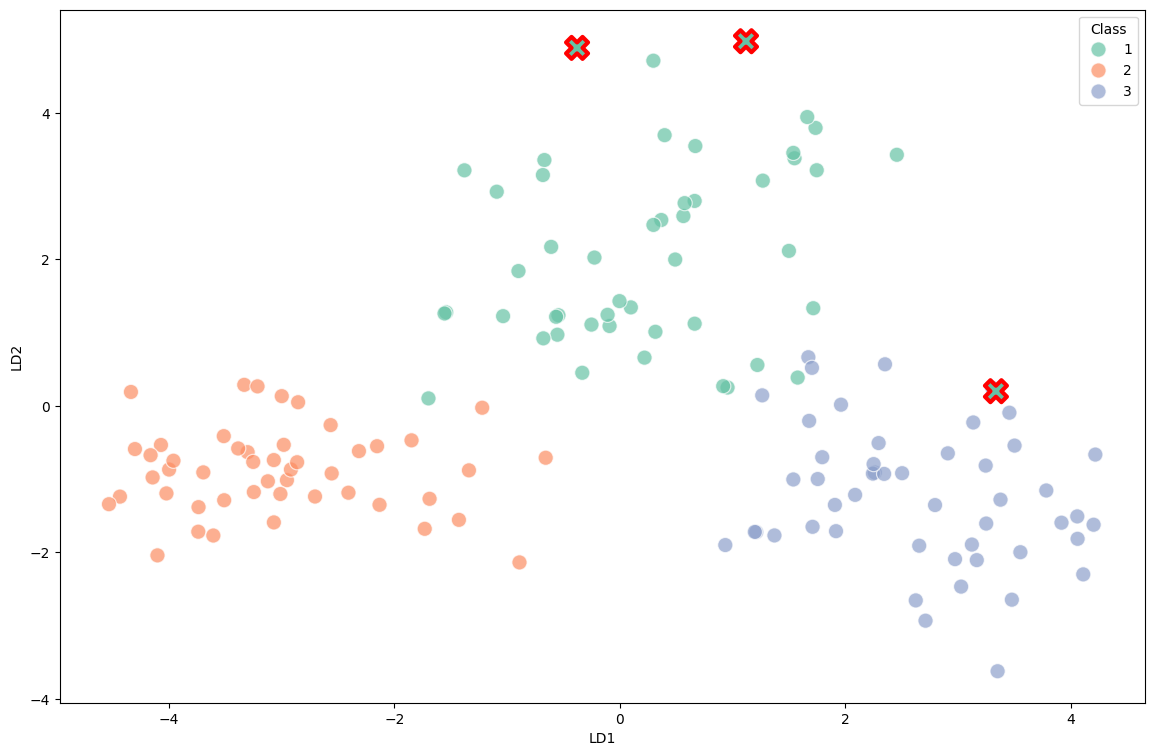

In [ ]:

# กำหนด Status: Normal หรือ Potential Outlier
lda_df_plot = lda_df.copy()
lda_df_plot['Status'] = 'Normal'
# ใช้ Threshold เดิม (Mean + 2.5 SD) เพื่อหาจุดที่หลุดฝูงจริงๆ
threshold = lda_df['Dist_from_Center'].mean() + 2.5 * lda_df['Dist_from_Center'].std()
lda_df_plot.loc[lda_df_plot['Dist_from_Center'] > threshold, 'Status'] = 'Potential Outlier'

# 2. สร้างกราฟ Scatter Plot
plt.figure(figsize=(14, 9))

# พล็อตจุดข้อมูลปกติ (Normal) โดยใช้ Palette เดิม ('Set2')
scatter = sns.scatterplot(data=lda_df_plot[lda_df_plot['Status'] == 'Normal'],
                        x='LD1', y='LD2', hue='Class',
                        palette='Set2', s=120, alpha=0.7, edgecolor='w', legend='full')

# พล็อตจุดข้อมูลที่เป็น Outlier โดยใช้สีแดงสดและเครื่องหมาย X เพื่อให้เด่นที่สุด
sns.scatterplot(data=lda_df_plot[lda_df_plot['Status'] == 'Potential Outlier'],
                x='LD1', y='LD2', hue='Class', palette='Set2', # ใช้สีตามคลาสเดิม
                marker='X', s=250, linewidth=3, edgecolor='red', # เพิ่มขอบแดง
                legend=False) # ไม่ต้องโชว์ Legend ซ้ำ

## **Linear discriminant analysis**

Linear discriminant analysis (LDA) is a supervised learning technique that can be used for classification, dimensionality reduction, feature extraction, clustering, or visualization.  
    It classifies the data points based on the LDA score and the posterior probability of each class. It evaluates the model’s performance using various metrics, such as the confusion matrix, the accuracy, the error rate, or the ROC curve.





### **Advantages of LDA**
- Simple and computationally efficient.
- Works well even when the number of features is much larger than the number of - training samples.
- Can handle multicollinearity.
### **Disadvantages of LDA**
- Assumes Gaussian distribution of data which may not always be the case.
- Assumes equal covariance matrices for different classes which may not hold in all datasets.
- Assumes linear separability which is not always true.
May not always perform well in high-dimensional feature spaces.

## Assumption

- The values of each predictor variable follow a normal distribution. If we created a histogram to visualize the data distribution for a particular predictor, it would essentially follow the “bell shape.”

    -->PowerTransformer (Aligh Non-Gaussian to Gaussian Dritribution)

- All predictor variables have the same variance. It is rarely the case in real-world data, thus we usually scale each variable to have the same mean and variance before building an LDA model.
    
    -->Standardization ( Adjust Mean as 0, Variance as 1)
   



- The features are independent of each other. It means that there is no correlation or dependence between the features and that the covariance matrix of the data is diagonal.

    --> The covariance matrix (Heatmap shows each class has similar variance)

- The classes are linearly separable. It means that a linear decision boundary can accurately classify the different classes.
